# COMPARE TEST

### IMPORTS

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from scripts.snp       import SNP
from scripts.baskets   import config
from scripts.portfolio import Portfolio
from scripts.compare   import Compare

ModuleNotFoundError: No module named 'scripts'

### COMPARE

✓ cached → data\mag7.parquet
=== Compare on Portfolio(n=4, K=2, λ=2.0, A=0.5) ===

[Brute force] ['AAPL', 'MSFT']  C = 0.001247
[QAOA]        H_C ground state E0 = -0.501087
              p=1: E = -0.349217  ratio = 0.6969  top = 1100
              p=2: E = -0.500646  ratio = 0.9991  top = 0011
              p=3: E = -0.500631  ratio = 0.9991  top = 1100

[QNN]         soft = 0.001190  hard = 0.001247

METHOD COMPARISON  (n=4, K=2, λ=2.0, A=0.5)
  Method                 Portfolio                          Cost   Ratio
----------------------------------------------------------------------
  Brute force            AAPL+MSFT                      0.001247  1.0000
  QAOA p=1 (top-1)       AAPL+MSFT                      0.001247  0.6969
  QAOA p=2 (top-1)       GOOGL+AMZN                     0.002182  0.9991
  QAOA p=3 (top-1)       AAPL+MSFT                      0.001247  0.9991
  QNN (hard select)      AAPL+MSFT                      0.001247       —
✓ saved → plots\compare\mag7_comparison.p

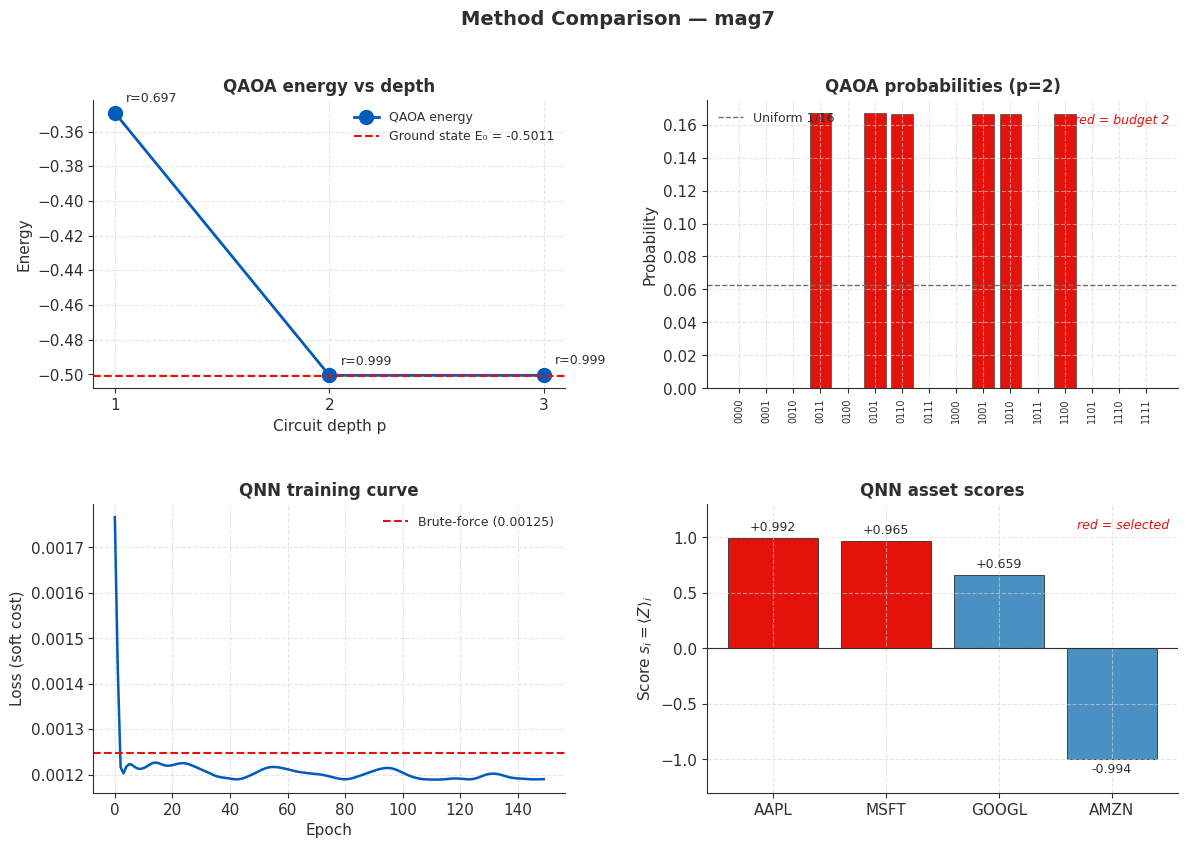

In [ ]:
tickers, start, end = config("mag7")
snp = SNP(tickers, start, end).cached_fetch(name="mag7")
pf = Portfolio(snp.mu, snp.Sigma, lam=2.0, A=0.5, K=2, tickers=snp.tickers)

cmp = Compare(pf).run(p_values=[1, 2, 3])
cmp.report()
cmp.plot(save=True, name="mag7")

### COMPARE ALL BASKETS

✓ cached → data\mag7.parquet


############################################################
# Basket: mag7
############################################################

METHOD COMPARISON  (n=4, K=2, λ=2.0, A=0.5)
  Method                 Portfolio                          Cost   Ratio
----------------------------------------------------------------------
  Brute force            AAPL+MSFT                      0.001247  1.0000
  QAOA p=1 (top-1)       AAPL+MSFT                      0.001247  0.6969
  QAOA p=2 (top-1)       GOOGL+AMZN                     0.002182  0.9991
  QAOA p=3 (top-1)       AAPL+MSFT                      0.001247  0.9991
  QNN (hard select)      AAPL+MSFT                      0.001247       —
✓ saved → plots\compare\mag7_comparison.pdf


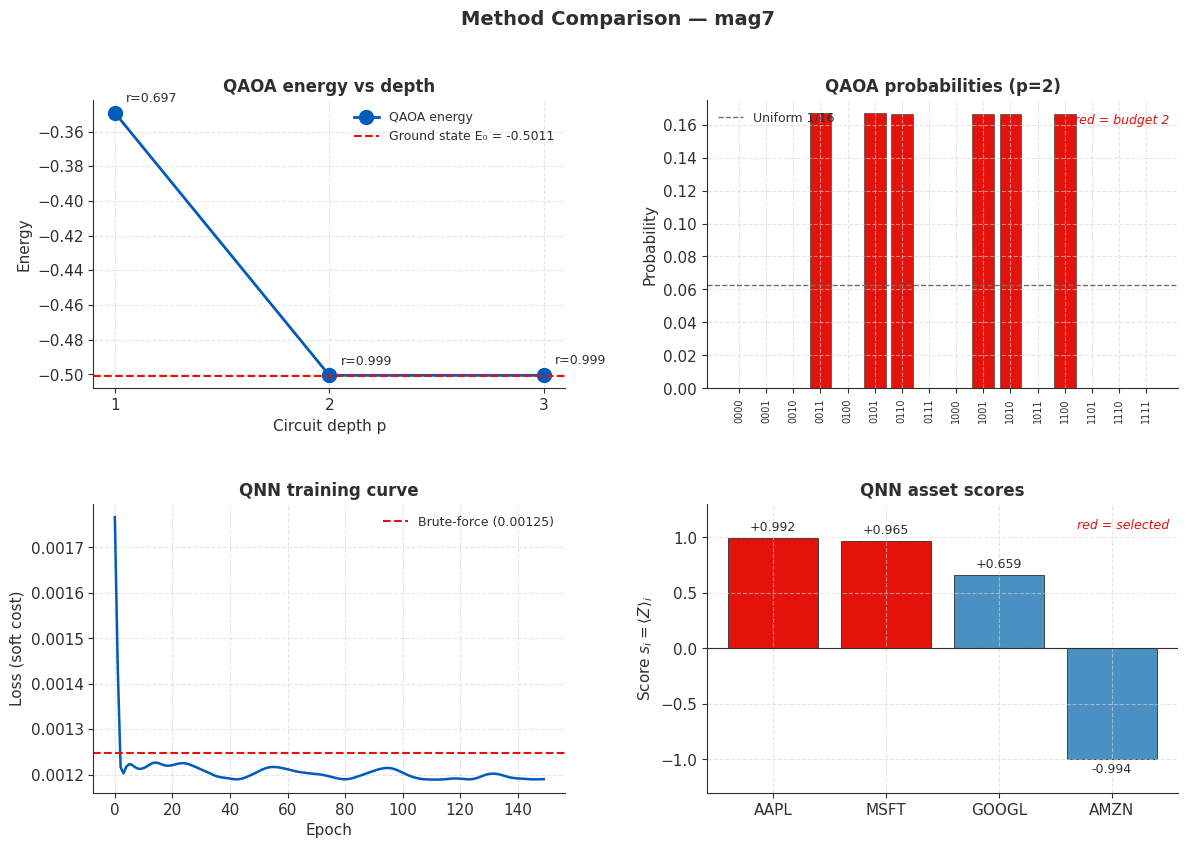

✓ cached → data\quantum.parquet


############################################################
# Basket: quantum
############################################################


KeyboardInterrupt: 

In [ ]:
from scripts.baskets import BASKETS, config

results = {}
for name in BASKETS:
    tickers, start, end = config(name)
    snp = SNP(tickers, start, end).cached_fetch(name=name)
    pf = Portfolio(snp.mu, snp.Sigma, lam=2.0, A=0.5, K=2, tickers=snp.tickers)
    print(f"\n\n{'#'*60}\n# Basket: {name}\n{'#'*60}")
    cmp = Compare(pf).run(p_values=[1, 2, 3], verbose=False)
    cmp.report()
    cmp.plot(save=True, name=name)
    results[name] = cmp